In [3]:
'''Corrected/debugged functions'''

import numpy as np
from fractions import Fraction
from QCT_util import Haar_state, dec2bin, U
from functools import partial
import scipy.sparse as sp   

class QCT():
    def __init__(self, L, p_ctrl, p_proj, seed_initial=None, seed_ctrl=None, seed_proj=None, seed_born=None, seed_scramble=None):
        self.L = L
        self.p_ctrl = p_ctrl
        self.p_proj = p_proj
        self.seed_ctrl = seed_ctrl
        self.seed_proj = seed_proj
        self.seed_born = seed_born
        self.seed_scramble = seed_scramble
        self.state = Haar_state(self.L, 1, rng=np.random.default_rng(seed_initial), k=1).flatten()

    def XL_tensor(self, state):
        if state.ndim != self.L:
            state = state.reshape((2,) * self.L)
        
        # Use np.roll to swap 0 and 1 indices in the last dimension
        state = np.roll(state, 1, axis=self.L-1)
        
        return state
    
    def apply_cyclic_shift_to_state(self, state, left = True):
        if state.ndim != self.L:
            state = state.reshape((2,) * self.L)
        if left:
        # Create index list for left shift: [1,2,3,...,L-1,0]
            idx_list = list(range(1,self.L)) + [0]
        else:
            idx_list = [self.L-1] + list(range(self.L-1))
        # Apply transpose and flatten
        return state.transpose(idx_list)
    
    def projection(self, state, pos, target):
        # Reshape state into tensor form
        if state.ndim != self.L:
            state = state.reshape((2,) * self.L) # reshape state into tensor form
        
        # Apply projections sequentially
        for p, t in zip(pos, target):
            idx = [slice(None)] * self.L
            idx[p] = 1 - t  # Zero out the opposite target state
            state[tuple(idx)] = 0
        # Compute norm directly on tensor form
        norm = np.sqrt(np.sum(np.abs(state)**2))
        if norm > 0:
            state = state / norm

        return state
    
    def born_prob(self, state, pos, target):
        if state.ndim != self.L:
            state = state.reshape((2,) * self.L)
        # Create index tuple for the desired position and target
        idx = [slice(None)] * self.L
        idx[pos] = target
        # Extract relevant amplitudes and compute probability
        selected_amplitudes = state[tuple(idx)].flatten()
        return (np.abs(selected_amplitudes)**2).sum()

    def measure_reset_rightmost_qubit(self, state, seed_born=None):
        # Initialize random number generator
        rng_born = np.random.default_rng(seed_born)

        # Reshape state into tensor form
        if state.ndim != self.L:
            state = state.reshape((2,) * self.L)
        
        # Measure
        p0 = self.born_prob(state, self.L-1, 0)
        target = 0 if rng_born.random() < p0 else 1
        
        # Project to measured state
        state = self.projection(state, [self.L-1], [target])

        if target == 1:
            state = self.XL_tensor(state)
                    
        return state, target

    def S_tensor(self, vec, rng=None):
        """Apply scrambler gate to the last two qubits. Directly convert to tensor and apply to the last two indices.

        Parameters
        ----------
        vec : numpy.array, shape=(2**L_T,) or (2,)*L_T
            state vector
        rng : numpy.random.Generator
            random number generator

        Returns
        -------
        numpy.array, 
            state vector after applying scrambler gate
        """
        U_4=U(4,rng=rng)
        vec=vec.reshape((2**(self.L-2),2**2)).T
        return (U_4@vec).T
    
    def adder(self, state):
        """Calculate the adder matrix, which is the shuffle of the state basis. Note that this is not a full adder, which assumes the leading digit in the input bitstring is zero (because of the T^{-1}R_L, the leading bit should always be zero).

        Returns
        -------
        numpy.array, shape=(2**L,2**L)
            adder matrix
        """
        int_1_6=dec2bin(Fraction(1,6), self.L)|1
        int_1_3=dec2bin(Fraction(1,3), self.L)

        old_idx=np.arange(2**(self.L-1))
        adder_idx=np.array([int_1_6]*2**(self.L-2)+[int_1_3]*2**(self.L-2))
        new_idx=(old_idx+adder_idx)
        ones=np.ones(2**(self.L-1))

        # handle the extra attractors, if 1..0x1, then 1..0(1-x)1, if 0..1x0, then 0..1(1-x)0 
        mask_1=(new_idx&(1<<self.L-1) == (1<<self.L-1)) & (new_idx&(1<<2) == (0)) & (new_idx&(1) == (1))
        mask_2=(new_idx&(1<<self.L-1) == (0)) & (new_idx&(1<<2) == (1<<2)) & (new_idx&(1) == (0))
        new_idx[mask_1+mask_2]=new_idx[mask_1+mask_2]^(0b10)
        # print(old_idx,new_idx)
        adder = sp.coo_matrix((ones,(new_idx,old_idx)),shape=(2**self.L,2**self.L))

        return adder @ state.flatten()

    def bernoulli_map(self, state, seed_scramble=None):
        """
        Apply the Bernoulli map to the quantum state.
        
        Parameters:
        state (np.ndarray): The state vector in the computational basis.
        
        Returns:
        np.ndarray: The new state vector after applying the Bernoulli map.
        """
        state = self.apply_cyclic_shift_to_state(state, left=True)
        state = self.S_tensor(state, rng = seed_scramble)
        return state

    def control_map(self, state, seed_born=None):
        """
        Apply the global control map to the quantum state.
        
        Parameters:
        state (np.ndarray): The state vector in the computational basis.
        
        Returns:
        np.ndarray: The new state vector after applying the global control map.
        """
        state, _ = self.measure_reset_rightmost_qubit(state, seed_born=seed_born)
        state = self.apply_cyclic_shift_to_state(state,left=False)
        state = self.adder(state)
        return state
    
    def op_dict(self):
        return {
            ('C',): partial(self.control_map),
            ('B',): partial(self.bernoulli_map),
            (f'P{self.L-1}', 0): partial(self.projection, pos=[self.L-1], target=[0]),
            (f'P{self.L-2}', 0): partial(self.projection, pos=[self.L-2], target=[0]),
            (f'P{self.L-1}', 1): partial(self.projection, pos=[self.L-1], target=[1]),
            (f'P{self.L-2}', 1): partial(self.projection, pos=[self.L-2], target=[1])
        }

    def step_evolution(self):
        '''
        Parameters:
        state (np.ndarray): The state vector in the computational basis.
        p_ctrl (float): The probability of control.
        p_proj (float): The probability of projection.
        seed (int): The seed for the random number generator for p_ctrl and p_proj.
        Returns:
        tuple: A tuple containing:
            - np.ndarray: The new state vector after applying the control map or the Bernoulli map.
            - str: The operator applied ('C' for control map, 'B' for Bernoulli map).
        '''

        rng_ctrl = np.random.default_rng(self.seed_ctrl)
        rng_proj = np.random.default_rng(self.seed_proj)
        rng_born = np.random.default_rng(self.seed_born)
        op_dict = self.op_dict()

        if rng_ctrl.random() < self.p_ctrl:
            self.state = op_dict[('C',)](self.state, seed_born=self.seed_born)
            applied_operator = ['C']
        else:
            self.state = op_dict[('B',)](self.state, seed_scramble=self.seed_scramble)
            applied_operator = ['B']

        # After applying the Bernoulli map, there is a projective probability to apply the projective measurement to
        # the last two qubits. 

        if 'B' in applied_operator:
            if rng_proj.random() < self.p_proj:
                for i, pos in enumerate([self.L-1, self.L-2]):
                    prob = self.born_prob(self.state, pos, 0)
                    if rng_born.random() < prob:
                        self.state = op_dict[(f'P{pos}', 0)](self.state)
                    else:
                        self.state = op_dict[(f'P{pos}', 1)](self.state)
                        applied_operator.append(f'P{pos}')
        return self.state, applied_operator


Processing L=8:   0%|          | 0/21 [00:00<?, ?it/s]

Processing L=8: 100%|██████████| 21/21 [24:24<00:00, 69.73s/it]      


Time taken for Tao's version: 1464.4240682125092 seconds


Processing L=8: 100%|██████████| 21/21 [18:10<00:00, 51.91s/it]      


Time taken for Haining's version: 1090.2024075984955 seconds


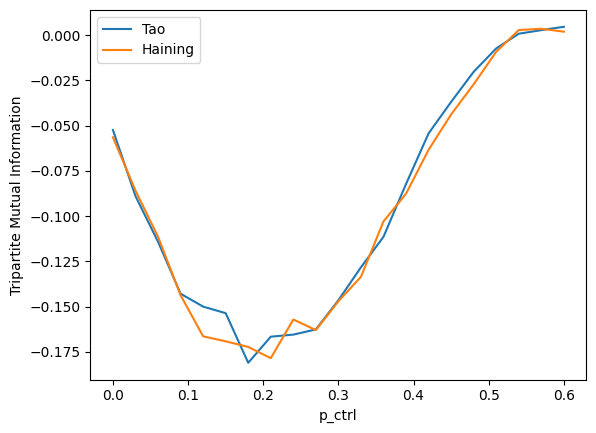

In [4]:
'''
Compare the tripartite mutual information of the toy model with different p_ctrl values between Tao's and Haining's version.
'''

import numpy as np
from corrected_functions import tripartite_mutual_information_tao
from haining_correct_functions import random_control, Haar_state
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

def compare_tmi(L_values, p_ctrl_values, p_proj, num_iterations):
    num_time_steps = { L : L**2*2 for L in L_values}
    
    for L in L_values:
        results = {'tao': [], 'haining': [], 'p_ctrl_values': p_ctrl_values.tolist()}
        time_start = time.time()
        for p_ctrl in tqdm(p_ctrl_values, desc=f"Processing L={L}"):
            qct = QCT(L, p_ctrl, p_proj)
            tao_tmi = 0
            for iter_idx in range(num_iterations):
                state = Haar_state(ensemble=1, rng=np.random.default_rng(), L=L).flatten()
                state_tao = state.copy()
                for step in range(num_time_steps[L]):
                    state_tao, _ = qct.step_evolution(state_tao)
                tao_tmi += tripartite_mutual_information_tao(state_tao, L)
                
            tao_tmi /= num_iterations
            results['tao'].append(tao_tmi)

        time_end = time.time()
        print(f"Time taken for Tao's version: {time_end - time_start} seconds")

        time_start = time.time()
        for p_ctrl in tqdm(p_ctrl_values, desc=f"Processing L={L}"):
            haining_tmi = 0
            for _ in range(num_iterations):
                state = Haar_state(ensemble=1, rng=np.random.default_rng(), L=L).flatten()
                state_haining = state.copy()
                for _ in range(num_time_steps[L]):
                    state_haining, _ = random_control(state_haining, p_ctrl, p_proj, L)
                haining_tmi += tripartite_mutual_information_tao(state_haining, L)
            haining_tmi /= num_iterations
            results['haining'].append(haining_tmi)
        time_end = time.time()
        print(f"Time taken for Haining's version: {time_end - time_start} seconds")
        
        return results
        
def plot_results(results):
    plt.plot(results['p_ctrl_values'], results['tao'], label='Tao')
    plt.plot(results['p_ctrl_values'], results['haining'], label='Haining')
    plt.xlabel('p_ctrl')
    plt.ylabel('Tripartite Mutual Information')
    plt.legend()
    plt.show()

results = compare_tmi([8], np.linspace(0, 0.6, 21), 0.3, 2000)
plot_results(results)